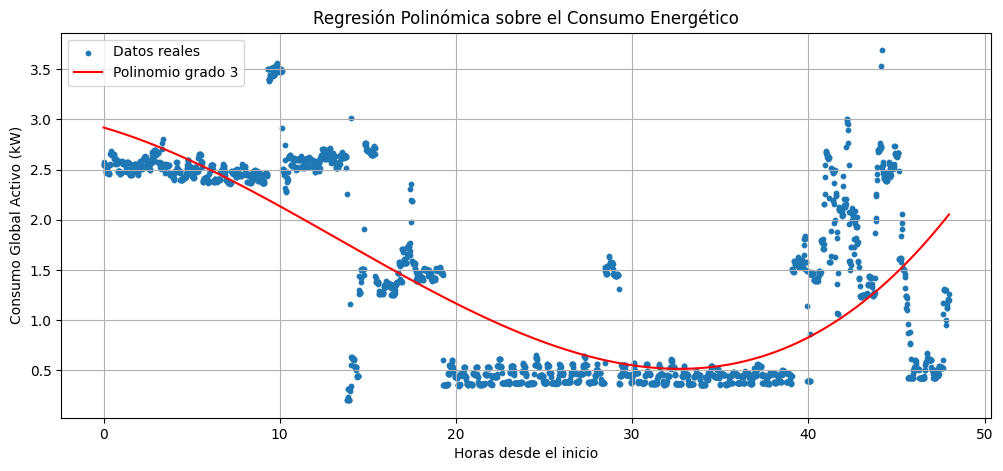

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

df = pd.read_csv('Datos/datos_limpios_parte_1.txt', sep=';')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)


subset = df['2007-01-01':'2007-01-02'].copy()
subset = subset.dropna(subset=['Global_active_power'])

subset['ts'] = (subset.index - subset.index[0]).total_seconds() / 3600  # horas desde el inicio

X = subset[['ts']].values
y = subset['Global_active_power'].values

grado = 3
poly = PolynomialFeatures(degree=grado)
X_poly = poly.fit_transform(X)

modelo = LinearRegression()
modelo.fit(X_poly, y)
y_pred = modelo.predict(X_poly)

plt.figure(figsize=(12, 5))
plt.scatter(X, y, label='Datos reales', s=10)
plt.plot(X, y_pred, color='red', label=f'Polinomio grado {grado}')
plt.xlabel('Horas desde el inicio')
plt.ylabel('Consumo Global Activo (kW)')
plt.title('Regresión Polinómica sobre el Consumo Energético')
plt.legend()
plt.grid(True)
plt.show()
